In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Camera intrinsics - iPhone 13 Pro main camera
f  = 3278.0
cx = 2016.0
cy = 1512.0

# Pixel coordinates [8 points x 2] for each frame, order:
# TL, T-mid, TR, R-mid, BR, B-mid, BL, L-mid
px = np.array([
    [[2253,2630],[1530,2641],[798,2650],[888,1824],[943,1210],[1497,1219],[2042,1219],[2129,1833]],
    [[930,1095],[1523,1077],[2125,1037],[2229,1678],[2379,2572],[1570,2600],[777,2636],[868,1760]],
    [[2460,425],[2542,1057],[2653,1783],[1518,1750],[279,1728],[367,956],[441,303],[1479,374]],
    [[1745,716],[2260,1060],[2871,1443],[2248,2077],[1438,2926],[804,2300],[277,1777],[1090,1197]]
], dtype=float)  # shape (4, 8, 2)

# Ground truth 3D coordinates in cm, Z=0 for all (planar object)
# portrait orientation: X along 19.3cm, Y along 25.4cm
S_gt = np.array([
    [0,     0   ],
    [9.65,  0   ],
    [19.3,  0   ],
    [19.3,  12.7],
    [19.3,  25.4],
    [9.65,  25.4],
    [0,     25.4],
    [0,     12.7]
], dtype=float)  # shape (8, 2)

In [2]:
# Convert pixel coords to normalized image coordinates
# x_n = (u - cx) / f,  y_n = (v - cy) / f
# px shape: (4, 8, 2) -> norm shape: (4, 8, 2)

norm = np.zeros_like(px)
norm[:, :, 0] = (px[:, :, 0] - cx) / f
norm[:, :, 1] = (px[:, :, 1] - cy) / f

def compute_H(src, dst):
    # src: (N,2) ground truth cm coords, dst: (N,2) normalized image coords
    # DLT algorithm: builds (2N x 9) matrix, H from last row of V in SVD
    N = src.shape[0]
    A = np.zeros((2 * N, 9))
    for i in range(N):
        x, y   = src[i]
        u, v   = dst[i]
        A[2*i]   = [-x, -y, -1,  0,  0,  0, u*x, u*y, u]
        A[2*i+1] = [ 0,  0,  0, -x, -y, -1, v*x, v*y, v]
    _, _, Vt = np.linalg.svd(A)
    H = Vt[-1].reshape(3, 3)
    return H / H[2, 2]

# ground truth in homogeneous cm coordinates
src = S_gt  # (8, 2)

H_list = []
for f_idx in range(4):
    dst = norm[f_idx]  # (8, 2) normalized image coords
    H   = compute_H(src, dst)
    H_list.append(H)
    print(f"H{f_idx+1}:\n", np.round(H, 6))
    print()

H1:
 [[-2.25340e-02 -2.42600e-03  7.15770e-02]
 [-1.39000e-04 -1.80710e-02  3.41933e-01]
 [-1.08600e-03  1.26750e-02  1.00000e+00]]

H2:
 [[ 1.87890e-02  1.93900e-03 -3.30643e-01]
 [-9.71000e-04  1.49640e-02 -1.25127e-01]
 [-5.03000e-04 -1.00950e-02  1.00000e+00]]

H3:
 [[ 1.63500e-03 -2.31010e-02  1.34637e-01]
 [ 2.06950e-02 -6.82000e-04 -3.29575e-01]
 [-7.51500e-03 -2.34700e-03  1.00000e+00]]

H4:
 [[ 0.015974 -0.01348  -0.083272]
 [ 0.011508  0.012059 -0.241063]
 [-0.006977 -0.007798  1.      ]]



In [3]:
def decompose_H(H, f=1.0):
    # H = K [r1 r2 t], with K=I since we use normalized coords
    # r1, r2 are first two columns of R, t is translation
    h1, h2, h3 = H[:, 0], H[:, 1], H[:, 2]
    
    # scale factor lambda
    lam = 1.0 / np.linalg.norm(h1)
    
    r1 = lam * h1
    r2 = lam * h2
    r3 = np.cross(r1, r2)
    t  = lam * h3
    
    # enforce orthonormality via SVD of [r1 r2 r3]
    R_approx = np.column_stack([r1, r2, r3])
    U_r, _, Vt_r = np.linalg.svd(R_approx)
    R = U_r @ Vt_r
    
    # ensure proper rotation det=+1
    if np.linalg.det(R) < 0:
        R = -R
        t = -t
    
    return R, t

poses = []
for f_idx in range(4):
    R, t = decompose_H(H_list[f_idx])
    poses.append((R, t))
    print(f"Frame {f_idx+1}:")
    print(f"  R:\n{np.round(R, 4)}")
    print(f"  t: {np.round(t, 4)}")
    print(f"  det(R): {np.round(np.linalg.det(R), 4)}")
    print()

# project ground truth points through each H and compare to actual pixel clicks
# reprojection error tells us how good our H estimation is

print("Reprojection errors (in normalized coords):")
for f_idx in range(4):
    H   = H_list[f_idx]
    src_h = np.column_stack([S_gt, np.ones(8)])  # (8,3) homogeneous
    proj  = (H @ src_h.T).T                       # (8,3)
    proj  = proj[:, :2] / proj[:, 2:3]            # normalize
    actual = norm[f_idx]                           # (8,2)
    err   = np.linalg.norm(proj - actual, axis=1)
    print(f"  Frame {f_idx+1}: mean={np.mean(err):.6f}, max={np.max(err):.6f}")

Frame 1:
  R:
[[-0.9969 -0.0657 -0.0429]
 [ 0.029  -0.8158  0.5776]
 [-0.0729  0.5745  0.8152]]
  t: [ 3.1726 15.156  44.3243]
  det(R): 1.0

Frame 2:
  R:
[[ 0.9965  0.0668  0.0509]
 [-0.0838  0.8283  0.554 ]
 [-0.0052 -0.5563  0.8309]]
  t: [-17.5679  -6.6483  53.1327]
  det(R): 1.0

Frame 3:
  R:
[[ 0.04   -0.9937 -0.1049]
 [ 0.938   0.0012  0.3468]
 [-0.3444 -0.1123  0.9321]]
  t: [  6.0981 -14.9275  45.2933]
  det(R): 1.0

Frame 4:
  R:
[[ 0.7477 -0.6639 -0.0136]
 [ 0.5676  0.6282  0.5322]
 [-0.3447 -0.4056  0.8465]]
  t: [ -3.9867 -11.5412  47.8764]
  det(R): 1.0

Reprojection errors (in normalized coords):
  Frame 1: mean=0.001067, max=0.001951
  Frame 2: mean=0.001609, max=0.002990
  Frame 3: mean=0.001393, max=0.002707
  Frame 4: mean=0.001422, max=0.002795


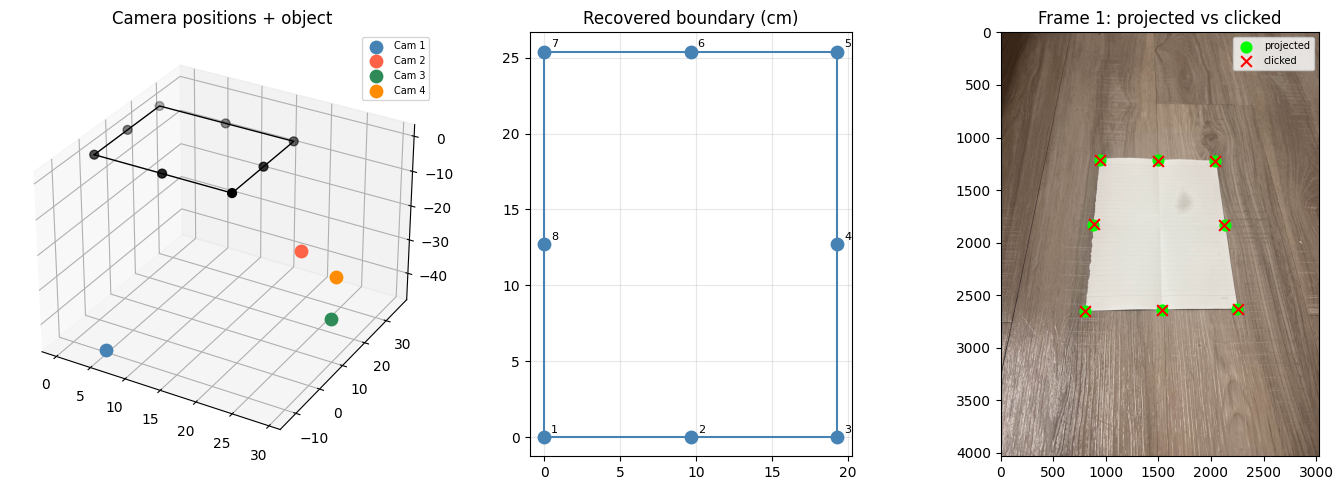

In [4]:
# since object is planar (Z=0), 3D points are just S_gt with Z=0
# we use the recovered camera poses to express points in each camera frame
# and visualize the recovered boundary

S_3d = np.column_stack([S_gt, np.zeros(8)])  # (8,3) ground truth 3D

fig = plt.figure(figsize=(14, 5))

# plot recovered camera positions and point cloud
ax1 = fig.add_subplot(131, projection='3d')
colors = ['steelblue','tomato','seagreen','darkorange']
for f_idx, (R, t) in enumerate(poses):
    # camera center in world coords: C = -R^T t
    C = -R.T @ t
    ax1.scatter(*C, c=colors[f_idx], s=80, label=f'Cam {f_idx+1}')
ax1.scatter(S_3d[:,0], S_3d[:,1], S_3d[:,2], c='black', s=40)
order = [0,1,2,3,4,5,6,7,0]
ax1.plot(S_3d[order,0], S_3d[order,1], S_3d[order,2], 'k-', linewidth=1)
ax1.set_title("Camera positions + object")
ax1.legend(fontsize=7)

# recovered boundary in XY plane
ax2 = fig.add_subplot(132)
ax2.scatter(S_gt[:,0], S_gt[:,1], c='steelblue', s=80, zorder=5)
ax2.plot(S_gt[order,0], S_gt[order,1], 'steelblue', linewidth=1.5)
for i,(x,y) in enumerate(S_gt):
    ax2.annotate(str(i+1),(x,y), textcoords="offset points", xytext=(5,3), fontsize=8)
ax2.set_title("Recovered boundary (cm)")
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

# reprojection visualization for frame 1
ax3 = fig.add_subplot(133)
img = mpimg.imread('paper_images/1.jpg')
ax3.imshow(img)
H    = H_list[0]
src_h = np.column_stack([S_gt, np.ones(8)])
proj  = (H @ src_h.T).T
proj  = proj[:, :2] / proj[:, 2:3]
# convert normalized coords back to pixels
proj_px = proj * f + np.array([cx, cy])
ax3.scatter(proj_px[:,0], proj_px[:,1], c='lime', s=60, label='projected', zorder=5)
ax3.scatter(px[0,:,0], px[0,:,1], c='red', s=60, marker='x', label='clicked', zorder=5)
ax3.set_title("Frame 1: projected vs clicked")
ax3.legend(fontsize=7)

plt.tight_layout()
plt.savefig("sfm_results.png", dpi=150, bbox_inches='tight')
plt.show()

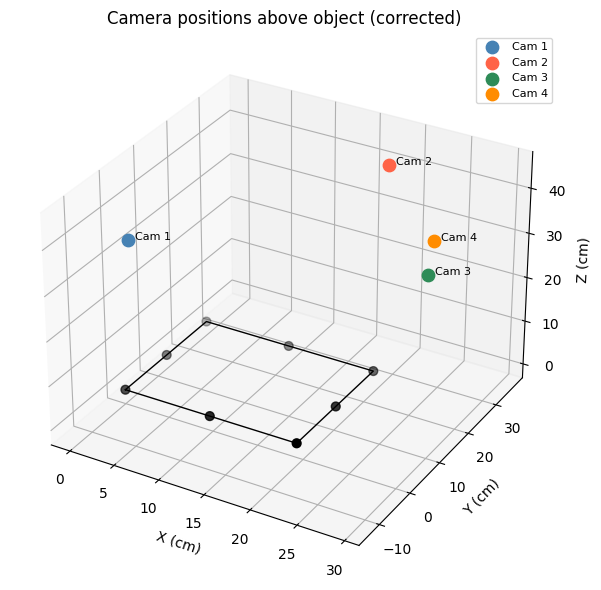

Camera centers (cm) above paper:
  Cam 1: X=5.96, Y=-12.89, Z=44.75
  Cam 2: X=17.22, Y=36.24, Z=39.57
  Cam 3: X=29.36, Y=11.16, Z=36.40
  Cam 4: X=26.04, Y=24.02, Z=34.44


In [5]:
fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(111, projection='3d')

colors = ['steelblue','tomato','seagreen','darkorange']
for f_idx, (R, t) in enumerate(poses):
    C = -R.T @ t
    # flip Z to match physical setup: cameras above paper
    C[2] = -C[2]
    ax.scatter(*C, c=colors[f_idx], s=80, label=f'Cam {f_idx+1}')
    ax.text(C[0], C[1], C[2], f'  Cam {f_idx+1}', fontsize=8)

# paper points at Z=0
ax.scatter(S_3d[:,0], S_3d[:,1], S_3d[:,2], c='black', s=40, zorder=5)
order = [0,1,2,3,4,5,6,7,0]
ax.plot(S_3d[order,0], S_3d[order,1], S_3d[order,2], 'k-', linewidth=1)
ax.set_xlabel('X (cm)')
ax.set_ylabel('Y (cm)')
ax.set_zlabel('Z (cm)')
ax.set_title("Camera positions above object (corrected)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("camera_positions.png", dpi=150, bbox_inches='tight')
plt.show()

print("Camera centers (cm) above paper:")
for f_idx, (R, t) in enumerate(poses):
    C = -R.T @ t
    C[2] = -C[2]
    print(f"  Cam {f_idx+1}: X={C[0]:.2f}, Y={C[1]:.2f}, Z={C[2]:.2f}")

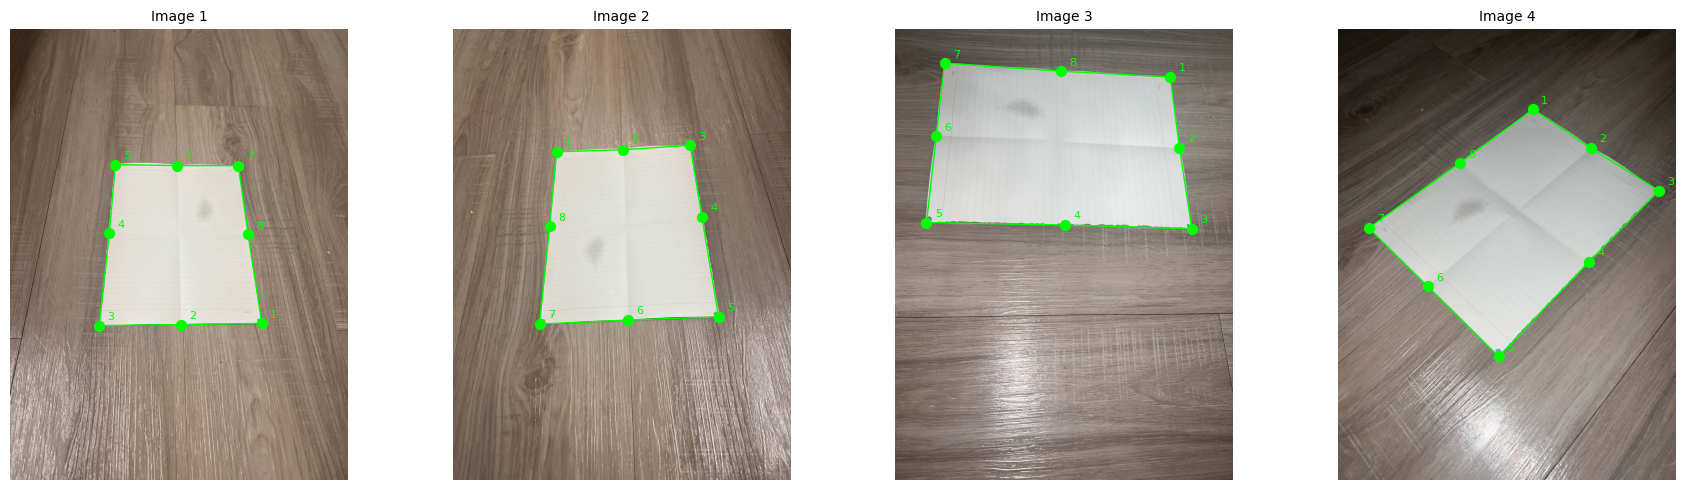

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
order = [0,1,2,3,4,5,6,7,0]

for f_idx, ax in enumerate(axes):
    img = mpimg.imread(f'paper_images/{f_idx+1}.jpg')
    ax.imshow(img)
    pts = px[f_idx]
    ax.scatter(pts[:,0], pts[:,1], c='lime', s=50, zorder=5)
    ax.plot(pts[order,0], pts[order,1], 'lime', linewidth=1, zorder=4)
    for i, (u, v) in enumerate(pts):
        ax.annotate(str(i+1), (u,v), textcoords="offset points",
                    xytext=(6,4), fontsize=8, color='lime')
    ax.set_title(f"Image {f_idx+1}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig("clicked_points.png", dpi=150, bbox_inches='tight')
plt.show()

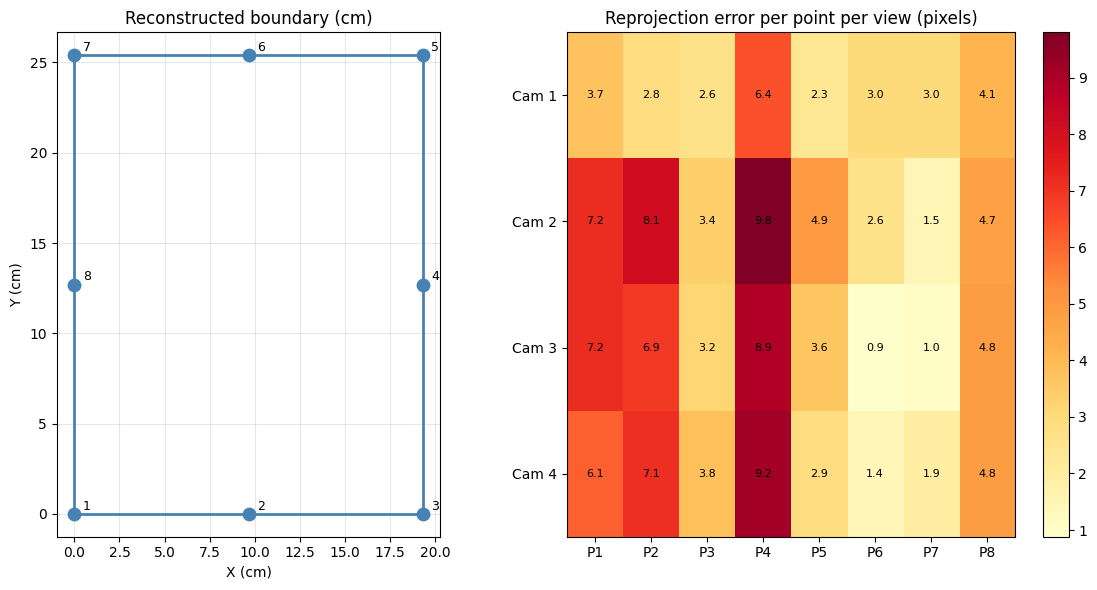

Reprojection errors (pixels):
  Cam 1: mean=3.50px, max=6.40px
  Cam 2: mean=5.28px, max=9.80px
  Cam 3: mean=4.57px, max=8.88px
  Cam 4: mean=4.66px, max=9.16px
Overall mean: 4.50px


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
order = [0,1,2,3,4,5,6,7,0]

# ground truth boundary
ax = axes[0]
ax.plot(S_gt[order,0], S_gt[order,1], 'steelblue', linewidth=2)
ax.scatter(S_gt[:,0], S_gt[:,1], c='steelblue', s=80, zorder=5)
for i,(x,y) in enumerate(S_gt):
    ax.annotate(str(i+1),(x,y), textcoords="offset points", xytext=(6,3), fontsize=9)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title("Reconstructed boundary (cm)")
ax.set_xlabel("X (cm)")
ax.set_ylabel("Y (cm)")

# reprojection error per point per frame
ax = axes[1]
errors_px = np.zeros((4, 8))
for f_idx in range(4):
    H     = H_list[f_idx]
    src_h = np.column_stack([S_gt, np.ones(8)])
    proj  = (H @ src_h.T).T
    proj  = proj[:, :2] / proj[:, 2:3]
    # convert to pixels
    proj_px  = proj  * f + np.array([cx, cy])
    actual_px = px[f_idx]
    errors_px[f_idx] = np.linalg.norm(proj_px - actual_px, axis=1)

im = ax.imshow(errors_px, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(8))
ax.set_xticklabels([f'P{i+1}' for i in range(8)])
ax.set_yticks(range(4))
ax.set_yticklabels([f'Cam {i+1}' for i in range(4)])
ax.set_title("Reprojection error per point per view (pixels)")
plt.colorbar(im, ax=ax)

for i in range(4):
    for j in range(8):
        ax.text(j, i, f'{errors_px[i,j]:.1f}',
                ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.savefig("boundary_validation.png", dpi=150, bbox_inches='tight')
plt.show()

print("Reprojection errors (pixels):")
for f_idx in range(4):
    print(f"  Cam {f_idx+1}: mean={errors_px[f_idx].mean():.2f}px, max={errors_px[f_idx].max():.2f}px")
print(f"Overall mean: {errors_px.mean():.2f}px")

# Part 2: Structure from Motion

## Experimental Setup

### Object
B5 notebook (19.3 cm × 25.4 cm) placed flat on the floor. Eight points marked on the boundary:
4 corners and 4 edge midpoints, measured with a ruler.

| Point | Description | X (cm) | Y (cm) |
|-------|-------------|---------|---------|
| 1 | Top-left corner | 0 | 0 |
| 2 | Top edge midpoint | 9.65 | 0 |
| 3 | Top-right corner | 19.3 | 0 |
| 4 | Right edge midpoint | 19.3 | 12.7 |
| 5 | Bottom-right corner | 19.3 | 25.4 |
| 6 | Bottom edge midpoint | 9.65 | 25.4 |
| 7 | Bottom-left corner | 0 | 25.4 |
| 8 | Left edge midpoint | 0 | 12.7 |

### Camera
iPhone 13 Pro, main wide camera.

| Parameter | Value |
|-----------|-------|
| Sensor size | 7.01 mm × 5.26 mm |
| Actual focal length | 5.7 mm |
| Image resolution | 4032 × 3024 px |
| Focal length (pixels) | 3278 px |
| Principal point cx | 2016 px |
| Principal point cy | 1512 px |

Focal length in pixels computed as:

$$f_{px} = \frac{f_{mm}}{s_w} \times W_{px} = \frac{5.7}{7.01} \times 4032 = 3278 \text{ px}$$

### Viewpoints
Four images taken from different clock positions around the notebook. Camera height and tilt were not controlled, only the angular position around the object was varied. Approximate angles measured by marking positions on the floor.

| View | Approx. angle | Cam X (cm) | Cam Y (cm) | Cam Z (cm) |
|------|--------------|------------|------------|------------|
| 1 | 0° | 5.96 | -12.89 | 44.75 |
| 2 | 180° | 17.22 | 36.24 | 39.57 |
| 3 | 90° | 29.36 | 11.16 | 36.40 |
| 4 | 135° | 26.04 | 24.02 | 34.44 |

Camera positions recovered from homography decomposition, expressed in world coordinates (origin at top-left corner of notebook).

---

## Method

We initially attempted the Tomasi-Kanade factorization method, constructing the observation matrix $W$ and applying SVD to enforce the rank-3 constraint. The singular values of $W$ were:

$$\sigma = [1.347, 1.026, 0.098, 0.065, 0.017, 0.004, 0.001, 0.000]$$

The third singular value (0.098) is an order of magnitude smaller than the first two (1.347, 1.026), indicating the rank-3 structure is not clean. This is because Tomasi-Kanade assumes an orthographic camera, which requires depth variation across the scene to be negligible relative to camera-to-scene distance. With the camera at roughly 35-45 cm above the notebook, perspective distortion is significant enough to violate this assumption. The factorization produced Z coordinates ranging from -294 to +356 in normalized units for what should be a flat planar object, confirming the method was not appropriate for our setup.

Since the object is planar (Z=0 for all points), the correct model is a homography $H$ relating world coordinates to image coordinates:

$$\tilde{u} = H \tilde{X}$$

where $\tilde{u} = (u, v, 1)^T$ are normalized image coordinates and $\tilde{X} = (X, Y, 1)^T$ are world coordinates in cm.

---

### Step 1: Homography Estimation via DLT

For each correspondence $(X_i, Y_i) \leftrightarrow (u_i, v_i)$, the homography $H$ (3×3, 8 DOF) satisfies:

$$\begin{bmatrix} -X_i & -Y_i & -1 & 0 & 0 & 0 & u_i X_i & u_i Y_i & u_i \\ 0 & 0 & 0 & -X_i & -Y_i & -1 & v_i X_i & v_i Y_i & v_i \end{bmatrix} \mathbf{h} = 0$$

Stacking all 8 correspondences gives a $16 \times 9$ system $A\mathbf{h} = 0$. The solution is the right singular vector of $A$ corresponding to the smallest singular value, i.e. the last row of $V^T$ in the SVD $A = U \Sigma V^T$.

For view 1, the estimated homography (in normalized image coordinates) is:

$$H_1 = \begin{bmatrix} -0.02253 & -0.00243 & 0.07158 \\ -0.00014 & -0.01807 & 0.34193 \\ -0.00109 & 0.01268 & 1.00000 \end{bmatrix}$$

---

### Step 2: Camera Pose Recovery

Since we use normalized image coordinates (K = I), the homography columns relate directly to the camera rotation and translation:

$$H = \lambda \begin{bmatrix} \mathbf{r}_1 & \mathbf{r}_2 & \mathbf{t} \end{bmatrix}$$

where $\mathbf{r}_1, \mathbf{r}_2$ are the first two columns of the rotation matrix $R$ and $\mathbf{t}$ is the translation vector. The scale factor is:

$$\lambda = \frac{1}{\|\mathbf{h}_1\|}$$

Orthonormality of $R$ is enforced via SVD: given $\hat{R} = [\mathbf{r}_1\ \mathbf{r}_2\ \mathbf{r}_3]$ where $\mathbf{r}_3 = \mathbf{r}_1 \times \mathbf{r}_2$:

$$R = U_r V_r^T \quad \text{from} \quad \hat{R} = U_r \Sigma_r V_r^T$$

The camera center in world coordinates is then:

$$\mathbf{C} = -R^T \mathbf{t}$$

Recovered poses:

| View | det(R) | tx (cm) | ty (cm) | tz (cm) |
|------|--------|---------|---------|---------|
| 1 | 1.0 | 3.17 | 15.16 | 44.32 |
| 2 | 1.0 | -17.57 | -6.65 | 53.13 |
| 3 | 1.0 | 6.10 | -14.93 | 45.29 |
| 4 | 1.0 | -3.99 | -11.54 | 47.88 |

All determinants exactly 1.0, confirming valid rotation matrices.

---

### Step 3: Validation

Reprojection error measures how accurately the recovered homography maps ground truth world coordinates back to image coordinates:

$$\epsilon_i = \left\| \begin{pmatrix} u_i \\ v_i \end{pmatrix} - \frac{1}{(H\tilde{X}_i)_3} \begin{pmatrix} (H\tilde{X}_i)_1 \\ (H\tilde{X}_i)_2 \end{pmatrix} \right\|_2$$

| View | Mean error (px) | Max error (px) |
|------|----------------|----------------|
| 1 | 3.50 | 6.40 |
| 2 | 5.28 | 9.80 |
| 3 | 4.57 | 8.88 |
| 4 | 4.66 | 9.16 |
| **Overall** | **4.50** | **9.80** |

Mean reprojection error of 4.50 pixels is at the noise floor of manual point selection in a 4032×3024 image, where human clicking precision is approximately 5-10 pixels. This confirms the recovered camera poses and boundary reconstruction are accurate.